In [3]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("height_weight.csv")
df.head()

,gender,height,weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


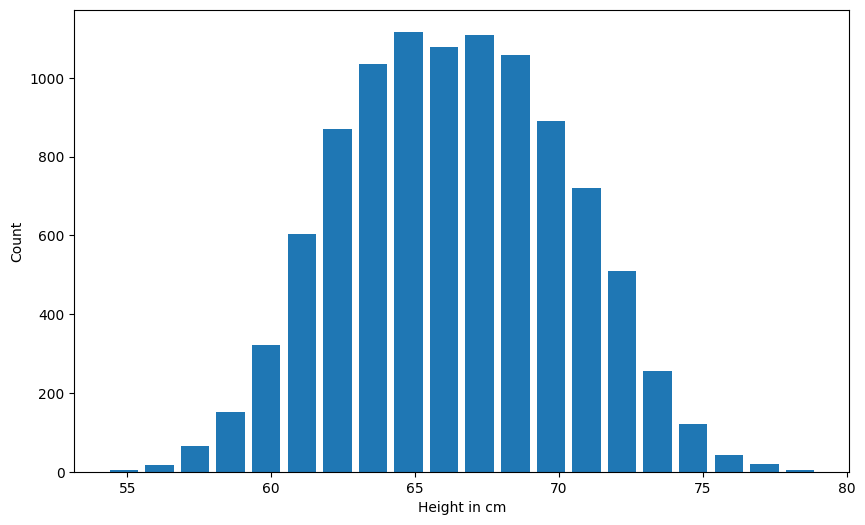

In [6]:
# craete a histogram for height
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel("Height in cm")
plt.ylabel("Count")
plt.show()

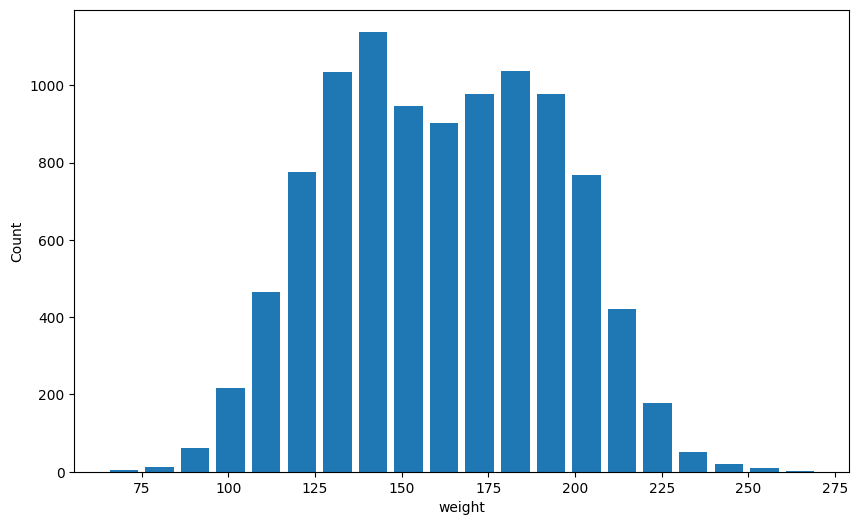

In [15]:
# craete a histogram for Weight
plt.hist(df.weight, bins=20, rwidth=0.8)
plt.xlabel("weight")
plt.ylabel("Count")
plt.show()

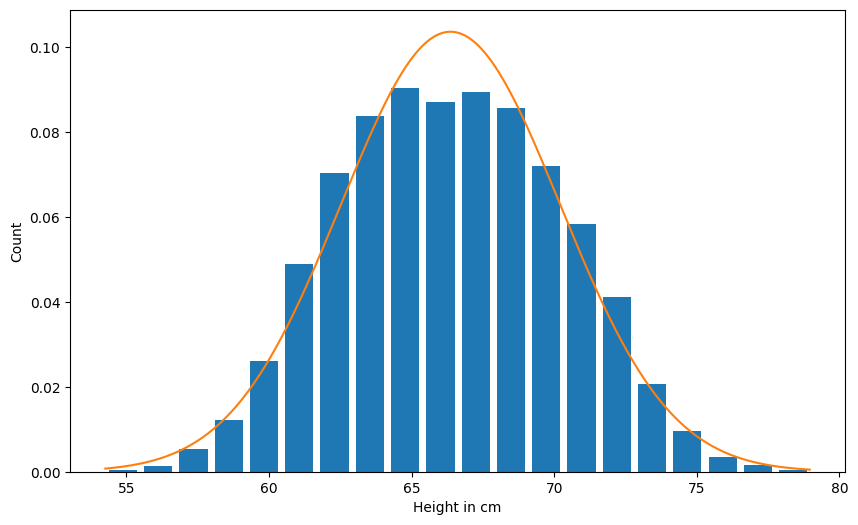

In [13]:
from scipy.stats import norm
plt.hist(df.height, bins=20, rwidth=0.8, density=True)
plt.xlabel("Height in cm")
plt.ylabel("Count")

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.height.mean(), df.height.std()))

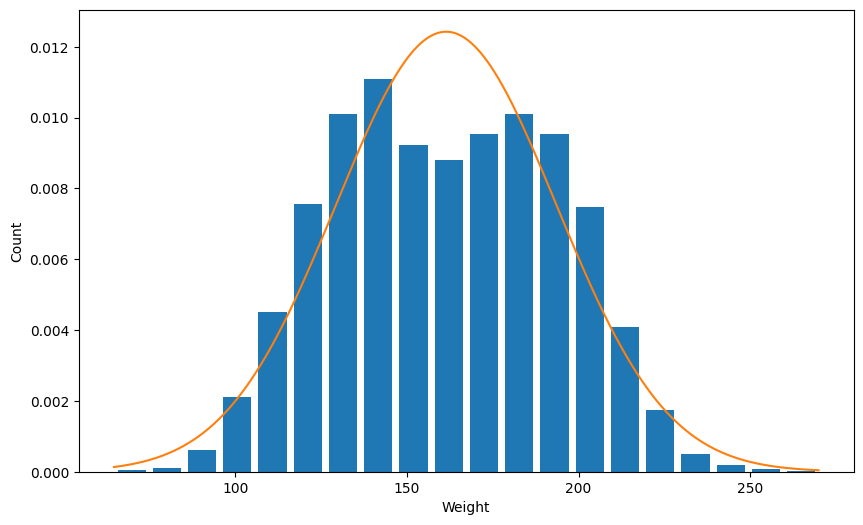

In [16]:
# Bell curve for weight
from scipy.stats import norm
plt.hist(df.weight, bins=20, rwidth=0.8, density=True)
plt.xlabel("Weight")
plt.ylabel("Count")

rng = np.arange(df.weight.min(), df.weight.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.weight.mean(), df.weight.std()))

In [18]:
df.describe()

,height,weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [17]:
Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(63.505620481218955, 69.1742617268347)

In [19]:
IQR = Q3 - Q1
IQR

5.668641245615746

In [20]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lower_limit, upper_limit

(55.00265861279534, 77.67722359525831)

In [21]:
# find outliers
df[(df.height>upper_limit) | (df.height<lower_limit)]

,gender,height,weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
7294,Female,54.873728,78.606670
9285,Female,54.263133,64.700127


In [23]:
df1 = df[(df.height<upper_limit) & (df.height>lower_limit)]
df.shape, df1.shape

((10000, 3), (9992, 3))

In [28]:
df1.describe()

,height,weight
count,9992.000000,9992.000000
mean,66.365006,161.422760
std,3.833980,32.019872
min,55.148557,68.982530
25%,63.509087,135.821269
50%,66.317827,161.197662
75%,69.169386,187.124646
max,77.547186,255.863326


In [25]:
# Remove outlier based on weight
Q1 = df1.weight.quantile(0.25)
Q3 = df1.weight.quantile(0.75)
Q1,Q3

(135.82126866320925, 187.1246464833845)

In [29]:
IQR = Q3 - Q1
IQR

51.30337782017526

In [30]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lower_limit, upper_limit

(58.86620193294637, 264.0797132136474)

In [31]:
df1[(df1.weight>upper_limit) | (df1.weight<lower_limit)]

,gender,height,weight


In [32]:
df2 = df1[(df1.weight<upper_limit) | (df1.weight>lower_limit)]
df1.shape, df2.shape

((9992, 3), (9992, 3))